# Análisis Word2Vec - Reseñas Turísticas de Costa Rica

**Proyecto 2: Análisis Semántico de Reseñas**

Este notebook entrena modelos Word2Vec (CBOW y Skip-Gram) con el corpus de reseñas y realiza análisis semánticos.

## 1. Importar librerías y configurar

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

# Importar módulos personalizados
from preprocessing import TextPreprocessor, load_corpus, get_tokenized_corpus
from w2v_utils import Word2VecTrainer, Word2VecAnalyzer, Word2VecVisualizer

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Cargar y preprocesar corpus

In [2]:
# Cargar corpus
df = load_corpus('../data/corpus.csv')
print(f"\nPrimeras reseñas:")
print(df[['texto', 'calificacion', 'tipo_lugar']].head(2))

Corpus cargado: 2116 reseñas
Columnas: ['texto', 'calificacion', 'tipo_lugar', 'fuente', 'fecha', 'lugar', 'polaridad']
Tipos de lugar: <StringArray>
['parque', 'restaurante', 'hotel']
Length: 3, dtype: str
Rango de calificaciones: 1.0-5.0

Primeras reseñas:
                                               texto  calificacion tipo_lugar
0  Tour fabuloso, bellísimo el bosque nuboso de M...           5.0     parque
1  Vale la pena ir a ver los puentes colgantes de...           4.0     parque


In [3]:
# Inicializar preprocesador
preprocessor = TextPreprocessor(
    language='spanish',
    remove_stopwords=True,
    use_lemma=False
)

# Obtener corpus tokenizado
tokenized_corpus = get_tokenized_corpus(df, preprocessor=preprocessor)

print(f"\nCorpus tokenizado:")
print(f"  Total de documentos: {len(tokenized_corpus)}")
print(f"  Tokens en primer documento: {len(tokenized_corpus[0])}")
print(f"  Ejemplo de tokens: {tokenized_corpus[0][:15]}")

# Estadísticas del corpus
total_tokens = sum(len(doc) for doc in tokenized_corpus)
vocab_size = len(set(token for doc in tokenized_corpus for token in doc))
avg_doc_length = total_tokens / len(tokenized_corpus)

print(f"\nEstadísticas:")
print(f"  Total de tokens: {total_tokens:,}")
print(f"  Tamaño vocabulario: {vocab_size:,}")
print(f"  Promedio tokens/documento: {avg_doc_length:.1f}")

Procesando textos: 100%|██████████| 2116/2116 [00:00<00:00, 3051.16it/s]


Corpus tokenizado:
  Total de documentos: 2116
  Tokens en primer documento: 29
  Ejemplo de tokens: ['fabuloso', 'bellísimo', 'bosque', 'nuboso', 'monteverde', 'circuito', 'puentes', 'colgantes', 'tras', 'almuerzo', 'visitamos', 'ranario', 'zona', 'pudimos', 'observar']

Estadísticas:
  Total de tokens: 47,629
  Tamaño vocabulario: 9,139
  Promedio tokens/documento: 22.5


## 3. Entrenar modelos Word2Vec

In [4]:
# Crear entrenador
trainer = Word2VecTrainer(
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42
)

# Entrenar CBOW
cbow_model = trainer.train_cbow(tokenized_corpus, epochs=30)

# Entrenar Skip-Gram
skipgram_model = trainer.train_skipgram(tokenized_corpus, epochs=30)

Entrenando CBOW...
✓ CBOW entrenado. Vocabulario: 2799 palabras
Entrenando Skip-Gram...
✓ Skip-Gram entrenado. Vocabulario: 2799 palabras


In [5]:
# Guardar modelos
trainer.save_model(cbow_model, '../data/models/cbow_model.bin')
trainer.save_model(skipgram_model, '../data/models/skipgram_model.bin')

print("✓ Modelos guardados")

✓ Modelo guardado en ../data/models/cbow_model.bin
✓ Modelo guardado en ../data/models/skipgram_model.bin
✓ Modelos guardados


## 4. Análisis Word2Vec

In [6]:
# Crear analizadores
cbow_analyzer = Word2VecAnalyzer(cbow_model)
skipgram_analyzer = Word2VecAnalyzer(skipgram_model)

print("=" * 60)
print("ANÁLISIS DE SIMILITUD")
print("=" * 60)

# Pares de palabras para analizar
similarity_pairs = [
    ('hotel', 'hospedaje'),
    ('bonito', 'hermoso'),
    ('volcán', 'naturaleza'),
    ('guía', 'conductor'),
    ('recomendado', 'excelente'),
    ('caro', 'expensive'),  # Pueden no estar en vocab
]

comparison_data = []

for word1, word2 in similarity_pairs:
    sim_cbow = cbow_analyzer.similarity(word1, word2)
    sim_skipgram = skipgram_analyzer.similarity(word1, word2)
    
    if sim_cbow is not None or sim_skipgram is not None:
        print(f"\n  {word1} <-> {word2}")
        if sim_cbow is not None:
            print(f"    CBOW: {sim_cbow:.4f}")
        else:
            print(f"    CBOW: N/A (palabra no en vocab)")
        
        if sim_skipgram is not None:
            print(f"    Skip-Gram: {sim_skipgram:.4f}")
        else:
            print(f"    Skip-Gram: N/A (palabra no en vocab)")
        
        comparison_data.append({
            'par': f"{word1}-{word2}",
            'CBOW': sim_cbow if sim_cbow is not None else 0,
            'Skip-Gram': sim_skipgram if sim_skipgram is not None else 0
        })

df_similarities = pd.DataFrame(comparison_data)
print(f"\n✓ {len(df_similarities)} pares analizados")

ANÁLISIS DE SIMILITUD

  hotel <-> hospedaje
    CBOW: 0.5132
    Skip-Gram: 0.3792

  bonito <-> hermoso
    CBOW: 0.5386
    Skip-Gram: 0.4120

  volcán <-> naturaleza
    CBOW: 0.4235
    Skip-Gram: 0.3084

  guía <-> conductor
    CBOW: 0.7899
    Skip-Gram: 0.5960

  recomendado <-> excelente
    CBOW: 0.6006
    Skip-Gram: 0.3574

✓ 5 pares analizados


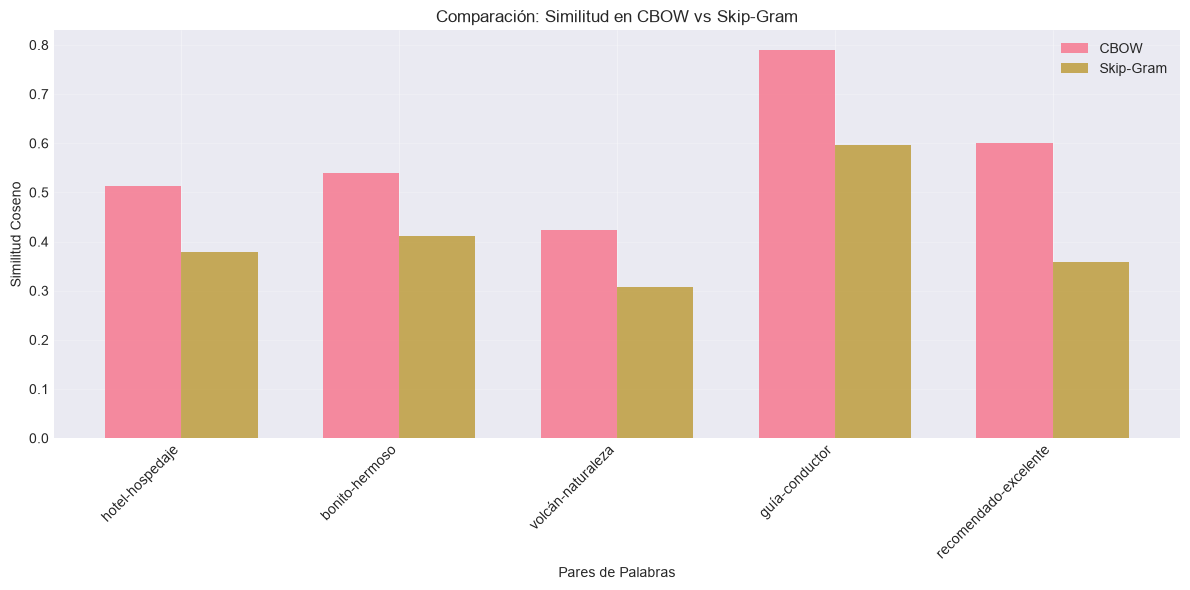

✓ Gráfico de similitudes generado


In [7]:
# Visualizar comparación de similitudes
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_similarities))
width = 0.35

ax.bar(x - width/2, df_similarities['CBOW'], width, label='CBOW', alpha=0.8)
ax.bar(x + width/2, df_similarities['Skip-Gram'], width, label='Skip-Gram', alpha=0.8)

ax.set_xlabel('Pares de Palabras')
ax.set_ylabel('Similitud Coseno')
ax.set_title('Comparación: Similitud en CBOW vs Skip-Gram')
ax.set_xticks(x)
ax.set_xticklabels(df_similarities['par'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Gráfico de similitudes generado")

### 4.2 Palabras más similares

In [8]:
print("=" * 60)
print("PALABRAS MÁS SIMILARES")
print("=" * 60)

test_words = ['hotel', 'volcán', 'guía', 'recomendado', 'bellísimo']

for word in test_words:
    print(f"\n📌 Similares a '{word}' (Skip-Gram):")
    similars = skipgram_analyzer.most_similar(word, topn=5)
    
    if similars:
        for similar, sim_score in similars:
            print(f"   - {similar}: {sim_score:.4f}")
    else:
        print(f"   [No se encontraron similares o palabra no en vocab]")

PALABRAS MÁS SIMILARES

📌 Similares a 'hotel' (Skip-Gram):
   - gustaron: 0.6048
   - atendido: 0.5890
   - colonial: 0.5889
   - recogida: 0.5886
   - aproximado: 0.5789

📌 Similares a 'volcán' (Skip-Gram):
   - barva: 0.6351
   - arenal: 0.6058
   - activo: 0.5959
   - poás: 0.5919
   - irazú: 0.5827

📌 Similares a 'guía' (Skip-Gram):
   - explicó: 0.6386
   - diego: 0.6297
   - arturo: 0.6256
   - bryan: 0.6160
   - didáctico: 0.6149

📌 Similares a 'recomendado' (Skip-Gram):
   - chiva: 0.5828
   - recomendada: 0.5502
   - increíblemente: 0.5314
   - mega: 0.5045
   - disfrutaron: 0.5040

📌 Similares a 'bellísimo' (Skip-Gram):
   - magico: 0.6149
   - desechos: 0.6116
   - principiantes: 0.6064
   - cumpleaños: 0.6027
   - intermedios: 0.5937


### 4.3 Analogías vectoriales

In [9]:
print("\n" + "=" * 60)
print("ANALOGÍAS VECTORIALES")
print("=" * 60)

# Definir analogías del dominio turístico
analogies = [
    ('hotel', 'habitación', 'restaurante', 'hotel → habitación como restaurante → ???'),
    ('volcán', 'naturaleza', 'playa', 'volcán → naturaleza como playa → ???'),
    ('guía', 'profesional', 'conductor', 'guía → profesional como conductor → ???'),
    ('viaje', 'largo', 'corto', 'viaje → largo como corto → ???'),
    ('actividad', 'divertida', 'aburrida', 'actividad → divertida como aburrida → ???'),
]

for word_a, word_b, word_c, description in analogies:
    print(f"\n  {description}")
    results = skipgram_analyzer.analogy(word_a, word_b, word_c, topn=3)
    
    if results:
        for i, (word, sim) in enumerate(results, 1):
            marker = "→" if i == 1 else " "
            print(f"    {marker} {word} (sim: {sim:.4f})")
    else:
        print(f"    [No se pudieron resolver]")


ANALOGÍAS VECTORIALES

  hotel → habitación como restaurante → ???
    → presentación (sim: 0.5170)
      deliciosas (sim: 0.4811)
      salsa (sim: 0.4805)

  volcán → naturaleza como playa → ???
    → curú (sim: 0.4841)
      calor (sim: 0.4778)
      quesera (sim: 0.4343)

  guía → profesional como conductor → ???
    → bryan (sim: 0.7229)
      luis (sim: 0.7181)
      mauricio (sim: 0.7084)

  viaje → largo como corto → ???
    → plano (sim: 0.6179)
      caídos (sim: 0.6155)
      enormes (sim: 0.6146)

  actividad → divertida como aburrida → ???
    [No se pudieron resolver]


### 4.4 Análisis por tipo de lugar

In [10]:
# Crear diccionario de textos por tipo_lugar
from preprocessing import split_by_category

texts_by_place = split_by_category(df, 'tipo_lugar')

# Tokenizar por tipo
tokens_by_place = {}
for place_type, texts in texts_by_place.items():
    tokens_by_place[place_type] = []
    for text in texts:
        tokens = preprocessor.process(text)
        tokens_by_place[place_type].extend(tokens)

print("\n" + "=" * 60)
print("VOCABULARIO POR TIPO DE LUGAR")
print("=" * 60)

vocab_analysis = []

for place_type, tokens in tokens_by_place.items():
    vocab_tokens = set(tokens)
    vocab_in_model = [t for t in vocab_tokens if t in skipgram_analyzer.wv]
    
    vocab_analysis.append({
        'tipo_lugar': place_type,
        'palabras_únicas': len(vocab_tokens),
        'en_modelo': len(vocab_in_model),
        'cobertura': f"{100*len(vocab_in_model)/len(vocab_tokens):.1f}%"
    })
    
    print(f"\n📍 {place_type}:")
    print(f"   Palabras únicas: {len(vocab_tokens)}")
    print(f"   En modelo: {len(vocab_in_model)}")
    print(f"   Cobertura: {100*len(vocab_in_model)/len(vocab_tokens):.1f}%")

df_vocab_analysis = pd.DataFrame(vocab_analysis)


VOCABULARIO POR TIPO DE LUGAR

📍 parque:
   Palabras únicas: 7882
   En modelo: 2711
   Cobertura: 34.4%

📍 restaurante:
   Palabras únicas: 766
   En modelo: 490
   Cobertura: 64.0%

📍 hotel:
   Palabras únicas: 2576
   En modelo: 1396
   Cobertura: 54.2%


In [11]:
# Top palabras por tipo de lugar
from collections import Counter

print("\n" + "=" * 60)
print("TOP PALABRAS POR TIPO DE LUGAR")
print("=" * 60)

for place_type, tokens in tokens_by_place.items():
    counter = Counter(tokens)
    top_words = counter.most_common(10)
    
    print(f"\n📍 {place_type}:")
    for word, count in top_words:
        print(f"   - {word}: {count}")


TOP PALABRAS POR TIPO DE LUGAR

📍 parque:
   - parque: 684
   - bien: 276
   - senderos: 275
   - ver: 238
   - bonito: 217
   - guía: 206
   - excelente: 197
   - playa: 193
   - experiencia: 190
   - puede: 185

📍 restaurante:
   - comida: 41
   - servicio: 29
   - excelente: 28
   - atención: 18
   - coco: 15
   - experiencia: 14
   - buena: 14
   - playa: 14
   - restaurante: 13
   - deliciosa: 12

📍 hotel:
   - atención: 66
   - excelente: 61
   - servicio: 55
   - buena: 54
   - bien: 52
   - vista: 52
   - habitaciones: 45
   - cartago: 44
   - desayuno: 42
   - hotel: 37


## 5. Visualizaciones t-SNE

In [12]:
# Preparar visualizador
visualizer = Word2VecVisualizer(skipgram_analyzer)

# Preparar datos t-SNE
print("Preparando proyección t-SNE (puede tardar)...")
vectors, words = visualizer.prepare_tsne_data(topn=300)

# Crear diccionario de categorías semánticas
semantic_categories = {
    'Naturaleza': ['volcán', 'naturaleza', 'puente', 'bosque', 'laguna', 'rio', 'agua', 'montaña'],
    'Alojamiento': ['hotel', 'habitación', 'hospedaje', 'cama', 'cuarto'],
    'Actividades': ['tour', 'excursión', 'actividad', 'recorrido', 'visita'],
    'Atributos': ['bueno', 'malo', 'bonito', 'hermoso', 'feo', 'excelente', 'malo'],
    'Personal': ['guía', 'conductor', 'personal', 'ayudante', 'anfitrión']
}

# Asignar categorías
word_categories = {}
for word in words:
    assigned = False
    for category, keywords in semantic_categories.items():
        if word in keywords:
            word_categories[word] = category
            assigned = True
            break
    if not assigned:
        word_categories[word] = 'Otro'

categories = [word_categories[w] for w in words]

# Calcular t-SNE
print("Calculando t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

print("✓ t-SNE completado")

Preparando proyección t-SNE (puede tardar)...
Calculando t-SNE...
✓ t-SNE completado


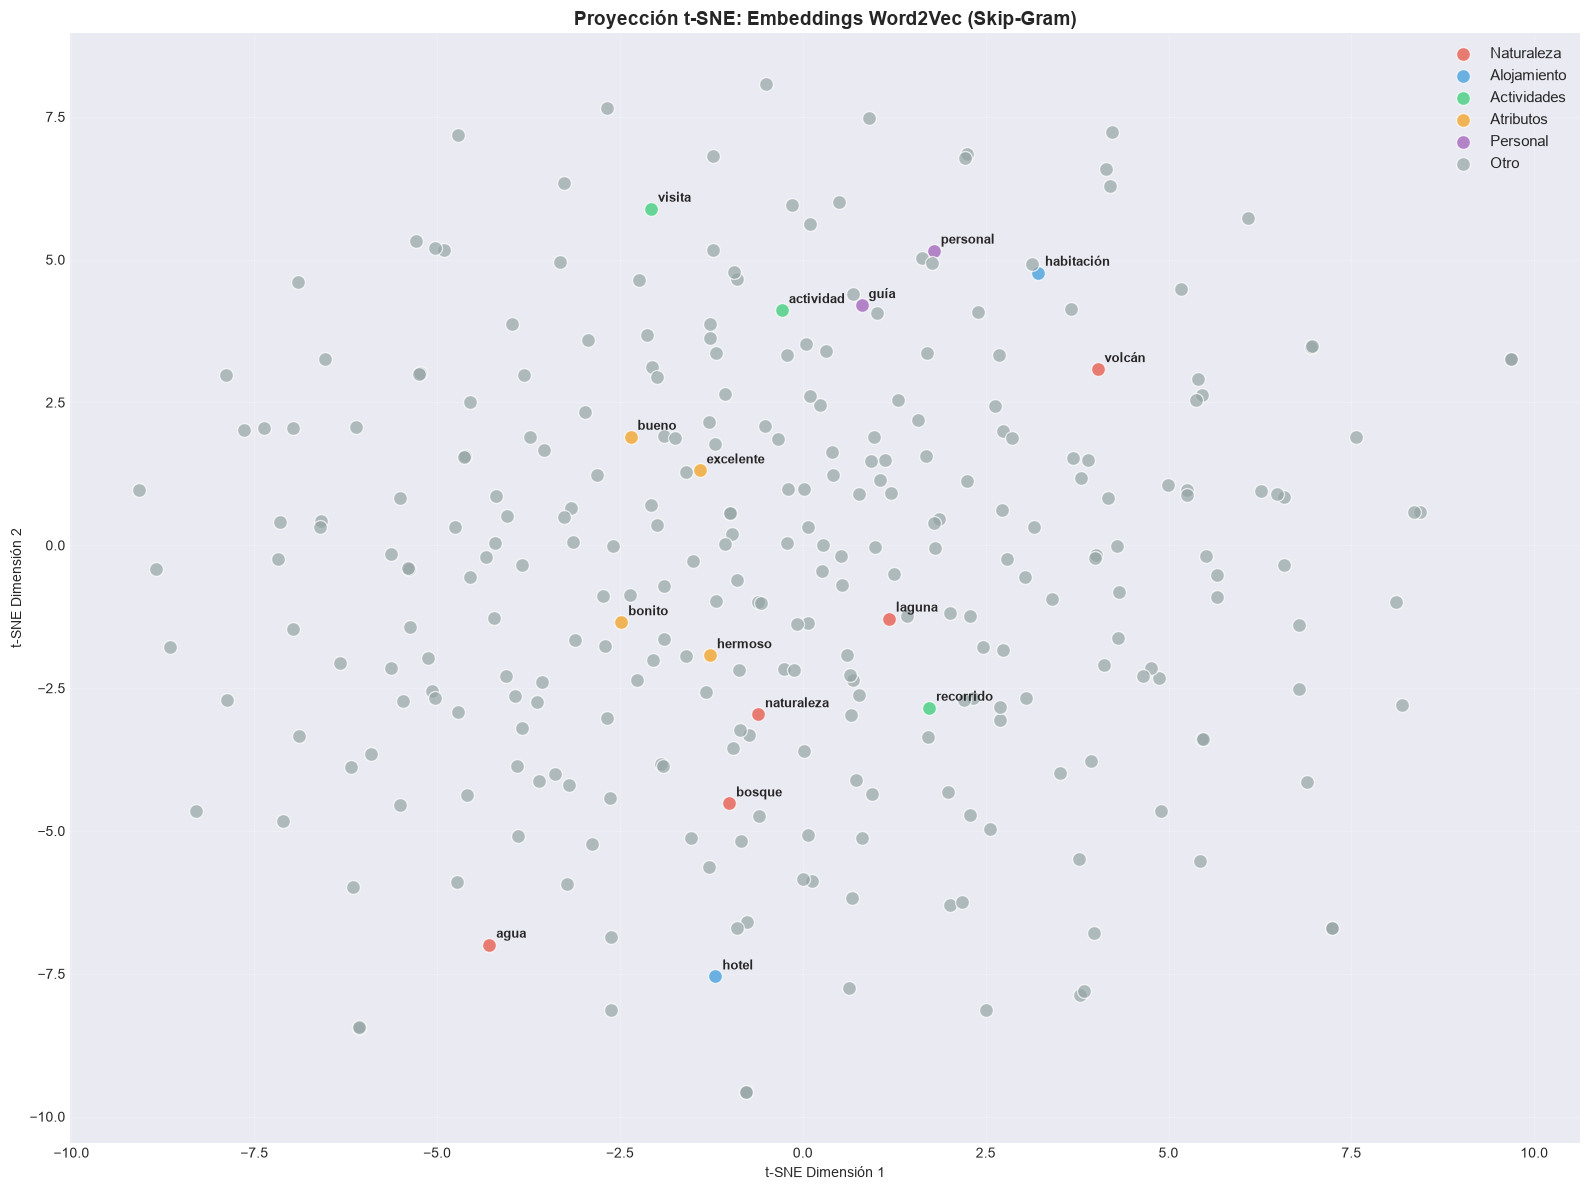

✓ Visualización t-SNE completada


In [13]:
# Visualizar t-SNE
fig, ax = plt.subplots(figsize=(16, 12))

# Colores por categoría
colors = {
    'Naturaleza': '#e74c3c',
    'Alojamiento': '#3498db',
    'Actividades': '#2ecc71',
    'Atributos': '#f39c12',
    'Personal': '#9b59b6',
    'Otro': '#95a5a6'
}

for category in colors.keys():
    indices = [i for i, c in enumerate(categories) if c == category]
    ax.scatter(vectors_2d[indices, 0], vectors_2d[indices, 1],
              c=colors[category], label=category, s=100, alpha=0.7, edgecolors='white', linewidth=1)

# Anotar palabras (solo las de categorías semánticas)
for i, word in enumerate(words):
    if word_categories[word] != 'Otro':
        ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                   fontsize=9, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points')

ax.set_title('Proyección t-SNE: Embeddings Word2Vec (Skip-Gram)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlabel('t-SNE Dimensión 1')
ax.set_ylabel('t-SNE Dimensión 2')
plt.tight_layout()
plt.show()

print("✓ Visualización t-SNE completada")

## 6. Guardar análisis

In [14]:
# Guardar analizadores
import pickle

with open('../data/models/cbow_analyzer.pkl', 'wb') as f:
    pickle.dump(cbow_analyzer, f)

with open('../data/models/skipgram_analyzer.pkl', 'wb') as f:
    pickle.dump(skipgram_analyzer, f)

# Guardar datos t-SNE
np.save('../data/visualizations/tsne_vectors_w2v.npy', vectors_2d)
with open('../data/visualizations/tsne_words_w2v.pkl', 'wb') as f:
    pickle.dump(words, f)
with open('../data/visualizations/tsne_categories_w2v.pkl', 'wb') as f:
    pickle.dump(categories, f)

# Guardar análisis
df_similarities.to_csv('../data/analysis/w2v_similarities.csv', index=False)
df_vocab_analysis.to_csv('../data/analysis/w2v_vocabulary_by_place.csv', index=False)

print("✓ Análisis guardados")
print("  - Analizadores: cbow_analyzer.pkl, skipgram_analyzer.pkl")
print("  - t-SNE: tsne_vectors_w2v.npy, tsne_words_w2v.pkl, tsne_categories_w2v.pkl")
print("  - Análisis: w2v_similarities.csv, w2v_vocabulary_by_place.csv")

✓ Análisis guardados
  - Analizadores: cbow_analyzer.pkl, skipgram_analyzer.pkl
  - t-SNE: tsne_vectors_w2v.npy, tsne_words_w2v.pkl, tsne_categories_w2v.pkl
  - Análisis: w2v_similarities.csv, w2v_vocabulary_by_place.csv


## 7. Resumen de resultados

In [15]:
print("\n" + "=" * 70)
print("RESUMEN: WORD2VEC ANALYSIS")
print("=" * 70)

print(f"\n📊 CORPUS:")
print(f"  • Total de reseñas: {len(df):,}")
print(f"  • Total de tokens: {total_tokens:,}")
print(f"  • Vocabulario único: {vocab_size:,}")
print(f"  • Promedio tokens/reseña: {avg_doc_length:.1f}")

print(f"\n🧠 MODELOS ENTRENADOS:")
print(f"  • CBOW - Vocabulario: {len(cbow_analyzer.wv):,}")
print(f"  • Skip-Gram - Vocabulario: {len(skipgram_analyzer.wv):,}")
print(f"  • Dimensión de embeddings: 300")
print(f"  • Ventana de contexto: 5")

print(f"\n📈 ANÁLISIS REALIZADOS:")
print(f"  • Similitudes entre palabras: {len(df_similarities)}")
print(f"  • Analogías vectoriales: {len(analogies)}")
print(f"  • Análisis por tipo de lugar: {len(df_vocab_analysis)}")
print(f"  • Proyección t-SNE: {len(words)} palabras")

print(f"\n✅ ARCHIVO GENERADOS:")
print(f"  • models/cbow_model.bin")
print(f"  • models/skipgram_model.bin")
print(f"  • models/cbow_analyzer.pkl")
print(f"  • models/skipgram_analyzer.pkl")
print(f"  • visualizations/tsne_vectors_w2v.npy")
print(f"  • analysis/w2v_similarities.csv")
print(f"  • analysis/w2v_vocabulary_by_place.csv")

print("\n" + "=" * 70)


RESUMEN: WORD2VEC ANALYSIS

📊 CORPUS:
  • Total de reseñas: 2,116
  • Total de tokens: 47,629
  • Vocabulario único: 9,139
  • Promedio tokens/reseña: 22.5

🧠 MODELOS ENTRENADOS:
  • CBOW - Vocabulario: 2,799
  • Skip-Gram - Vocabulario: 2,799
  • Dimensión de embeddings: 300
  • Ventana de contexto: 5

📈 ANÁLISIS REALIZADOS:
  • Similitudes entre palabras: 5
  • Analogías vectoriales: 5
  • Análisis por tipo de lugar: 3
  • Proyección t-SNE: 300 palabras

✅ ARCHIVO GENERADOS:
  • models/cbow_model.bin
  • models/skipgram_model.bin
  • models/cbow_analyzer.pkl
  • models/skipgram_analyzer.pkl
  • visualizations/tsne_vectors_w2v.npy
  • analysis/w2v_similarities.csv
  • analysis/w2v_vocabulary_by_place.csv



## 8. Centroides y vocabulario característico

In [16]:
# Centroides por tipo de lugar y polaridad + vocabulario característico
from sklearn.metrics.pairwise import cosine_similarity

def embedding_documento(tokens, wv):
    vectores = [wv[token] for token in tokens if token in wv]
    return np.mean(vectores, axis=0) if vectores else np.zeros(wv.vector_size)

df_centroides = df.copy()
df_centroides["tokens_w2v"] = tokenized_corpus
df_centroides["embedding_w2v"] = [embedding_documento(tokens, skipgram_analyzer.wv) for tokens in tokenized_corpus]

grupos = {}
for columna in ["tipo_lugar", "polaridad"]:
    for categoria, subset in df_centroides.groupby(columna):
        grupos[f"{columna}:{categoria}"] = np.mean(np.vstack(subset["embedding_w2v"]), axis=0)

nombres_grupos = list(grupos)
matriz_centroides = cosine_similarity(np.vstack([grupos[nombre] for nombre in nombres_grupos]))
df_centroid_similarity = pd.DataFrame(matriz_centroides, index=nombres_grupos, columns=nombres_grupos)
display(df_centroid_similarity.round(3))
df_centroid_similarity.to_csv("../data/analysis/w2v_centroid_similarities.csv")

filas_vocabulario = []
for nombre, centroide in grupos.items():
    otros = [grupos[otro] for otro in nombres_grupos if otro != nombre and otro.split(":")[0] == nombre.split(":")[0]]
    candidatos = []
    for palabra in skipgram_analyzer.wv.index_to_key:
        vector = skipgram_analyzer.wv[palabra]
        propio = cosine_similarity([vector], [centroide])[0, 0]
        contraste = max((cosine_similarity([vector], [otro])[0, 0] for otro in otros), default=0)
        candidatos.append((palabra, propio, propio - contraste))
    for rango, (palabra, similitud, distintividad) in enumerate(sorted(candidatos, key=lambda x: x[2], reverse=True)[:15], 1):
        filas_vocabulario.append({"grupo": nombre, "rango": rango, "palabra": palabra, "similitud_centroide": similitud, "distintividad": distintividad})

df_vocabulario_caracteristico = pd.DataFrame(filas_vocabulario)
display(df_vocabulario_caracteristico)
df_vocabulario_caracteristico.to_csv("../data/analysis/w2v_characteristic_vocabulary.csv", index=False)
print("Se guardaron centroides y vocabulario distintivo por tipo de lugar y polaridad.")


,tipo_lugar:hotel,tipo_lugar:parque,tipo_lugar:restaurante,polaridad:negativa,polaridad:neutral,polaridad:positiva
tipo_lugar:hotel,1.000,0.933,0.951,0.939,0.946,0.953
tipo_lugar:parque,0.933,1.000,0.882,0.934,0.979,0.998
tipo_lugar:restaurante,0.951,0.882,1.000,0.889,0.886,0.907
polaridad:negativa,0.939,0.934,0.889,1.000,0.978,0.934
polaridad:neutral,0.946,0.979,0.886,0.978,1.000,0.976
polaridad:positiva,0.953,0.998,0.907,0.934,0.976,1.000


,grupo,rango,palabra,similitud_centroide,distintividad
0,tipo_lugar:hotel,1,cartago,0.619918,0.105265
1,tipo_lugar:hotel,2,paredes,0.556891,0.092227
2,tipo_lugar:hotel,3,cables,0.579887,0.091921
3,tipo_lugar:hotel,4,jacuzzi,0.710452,0.090685
4,tipo_lugar:hotel,5,accesibilidad,0.740026,0.089483
...,...,...,...,...,...
85,polaridad:positiva,11,puntual,0.682587,0.096038
86,polaridad:positiva,12,magico,0.681284,0.095845
87,polaridad:positiva,13,geniales,0.676839,0.095367
88,polaridad:positiva,14,rodeados,0.727366,0.094396


Se guardaron centroides y vocabulario distintivo por tipo de lugar y polaridad.
